In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
## First see current path then run it 
import os
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\ASUS\Desktop\mlprojects\notebook\data


In [3]:
df = pd.read_csv('titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Handle Missing Values

In [4]:
missing_data = pd.DataFrame({
    'Columns': df.columns,
    'Rows': len(df),
    'Dtype': df.dtypes.values,
    'Missing Count': df.isnull().sum().values,
    'Missing Percentage': (df.isnull().sum().values / len(df)) *100
}).sort_values('Missing Percentage', ascending=False).round(2)

In [5]:
print("Missing Summary of Dataset:\n", missing_data)

Missing Summary of Dataset:
         Columns  Rows    Dtype  Missing Count  Missing Percentage
10        Cabin   891      str            687               77.10
5           Age   891  float64            177               19.87
11     Embarked   891      str              2                0.22
0   PassengerId   891    int64              0                0.00
3          Name   891      str              0                0.00
2        Pclass   891    int64              0                0.00
1      Survived   891    int64              0                0.00
4           Sex   891      str              0                0.00
7         Parch   891    int64              0                0.00
6         SibSp   891    int64              0                0.00
9          Fare   891  float64              0                0.00
8        Ticket   891      str              0                0.00


## Check Missingness is Random or Systematic

In [6]:
## Check if missing cabin correlates with Survival
print("\n Survival rate by Cabin availability:")
print(df.groupby(df['Cabin'].notna())['Survived'].mean())


 Survival rate by Cabin availability:
Cabin
False    0.299854
True     0.666667
Name: Survived, dtype: float64


In [7]:
# Check if missing Age correlates with Pclass
print(df.groupby('Pclass')['Age'].apply(lambda x: x.isna().mean()))

Pclass
1    0.138889
2    0.059783
3    0.276986
Name: Age, dtype: float64


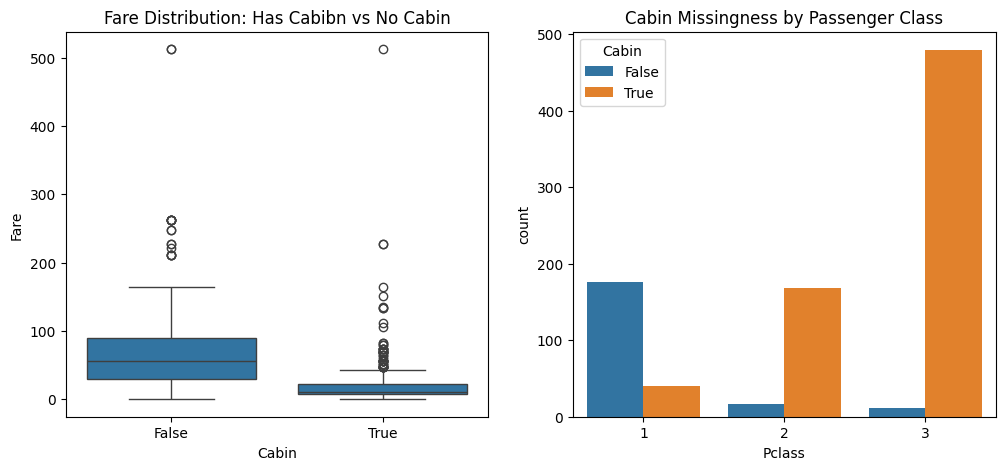

In [8]:
## Understand the relationships
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['Cabin'].isna(), y=df['Fare'])
plt.title("Fare Distribution: Has Cabibn vs No Cabin")

plt.subplot(1,2,2)
sns.countplot(x='Pclass', data=df, hue=df['Cabin'].isna())
plt.title("Cabin Missingness by Passenger Class")
plt.show()

## To Handle Missing Values:
->First Extract the information from the Cabin

->make Has_cabin: where it show 0 is for Yes has Cabin and 0 for No cabin

In [9]:
df['Deck'] =df['Cabin'].str[0] # Extract available info
df['Has_Cabin'] = df['Cabin'].notna().astype(int)

In [10]:
## After Extracting information from Cabin Drop it
df = df.drop('Cabin', axis = 1)

In [11]:
## Fill Embarked Feature with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [12]:
## Fill Age Feature by Using Groupby Pclass and Age
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [13]:
# Create Flag for missing Deck (already have Has_Cabin = 0)
df['Deck'] = df['Deck'].fillna('Unknown')

## Has_Cabin = 0 tells us:
->Passenger likely in 3rd class

->Paid lower fare

->Much lower chance of survival

->Missing cabin is actually INFORMATIVE!

Deck letter tells us:

->Exact location on ship.

->Social class (A-D = rich, E-G = poor).

->Proximity to lifeboats.

->Expected survival probability.

Together they provide:

->A complete picture of passenger status.

->Strong features for machine learning models.

->Preserved all information from original Cabin column.

->Handled missing values intelligently.

In [14]:
df = df.drop('Deck', axis=1)

In [15]:
df.shape

(891, 12)

In [16]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


## Find Skewness

In [17]:
skew_value = df.select_dtypes(include=['float64','int64']).skew()

## Handle Skewness

In [18]:
## Log Transformation for Fare
df['Fare_log'] = np.log1p(df['Fare'])

In [19]:
## Sqrt Transformation for Sibsp and Parch
df['SibSp_sqrt'] = np.sqrt(df['SibSp'])
df['Parch_sqrt'] = np.sqrt(df['Parch'])

## Outliers

In [20]:
numerical_features = df.select_dtypes(include=['float64', 'int64'])

In [21]:
outliers_res = []
for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    ## Outlier Bound
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    ## Find Outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(outliers)
    outliers_pct = (outliers_count / len(df)) * 100

    outliers_res.append({
    'col': col,
    'Outliers count': outliers_count,
    'Outliers Percentage':round(outliers_pct, 2),
    'Status': 'High' if outliers_pct > 10 else 'Mod' if outliers_pct > 5 else 'Low' if outliers_pct > 0
        else 'None'
    })

## Handle Outliers

In [22]:
## Age, Sibsp and Parch Can't be Negative so i Capped 
df['Age_handle'] = df['Age'].clip(upper=65.634)

df['SibSp_handle'] = df['SibSp'].clip(upper=4)
df['Parch_handle'] = df['Parch'].clip(upper=4)

In [23]:
## Fare Binning / Grouping
df['Fare_Binned'] = pd.qcut(df['Fare'], q=5, 
                            labels=['Very_Low', 'Low', 'Medium', 'High', 'Very_High'])

In [24]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Fare_log,SibSp_sqrt,Parch_sqrt,Age_handle,SibSp_handle,Parch_handle,Fare_Binned
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2.110213,1.0,0.0,22.0,1,0,Very_Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,4.280593,1.0,0.0,38.0,1,0,Very_High
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,2.188856,0.0,0.0,26.0,0,0,Low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,3.990834,1.0,0.0,35.0,1,0,Very_High
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,2.202765,0.0,0.0,35.0,0,0,Low


In [25]:
df = df.drop(['Fare', 'Age', 'SibSp', 'Parch'], axis=1)

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Ticket,Embarked,Has_Cabin,Fare_log,SibSp_sqrt,Parch_sqrt,Age_handle,SibSp_handle,Parch_handle,Fare_Binned
0,1,0,3,"Braund, Mr. Owen Harris",male,A/5 21171,S,0,2.110213,1.0,0.0,22.0,1,0,Very_Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C,1,4.280593,1.0,0.0,38.0,1,0,Very_High
2,3,1,3,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,S,0,2.188856,0.0,0.0,26.0,0,0,Low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,S,1,3.990834,1.0,0.0,35.0,1,0,Very_High
4,5,0,3,"Allen, Mr. William Henry",male,373450,S,0,2.202765,0.0,0.0,35.0,0,0,Low


In [27]:
# First, let's examine the Ticket feature
print("TICKET FEATURE ANALYSIS")
print("="*60)

# Check basic information
print("\n1. Basic Information:")
print(f"Total tickets: {len(df['Ticket'])}")
print(f"Unique tickets: {df['Ticket'].nunique()}")
print(f"Duplicate tickets: {len(df) - df['Ticket'].nunique()}")

TICKET FEATURE ANALYSIS

1. Basic Information:
Total tickets: 891
Unique tickets: 681
Duplicate tickets: 210


In [28]:
# Sample different types of tickets
print("\n2. Sample of ticket formats:")
sample_tickets = df['Ticket'].dropna().sample(10).values
for ticket in sample_tickets:
    print(f"  {ticket}")


2. Sample of ticket formats:
  336439
  237789
  S.O./P.P. 3
  230080
  SC/PARIS 2167
  113510
  F.C.C. 13531
  113807
  C.A. 33112
  364506


## Feature Extraction

In [29]:
print("NAME FEATURE EXTRACTION")
print("="*60)

# First, let's analyze what's in the Name feature
print("\n1. SAMPLE OF NAMES:")
print(df['Name'].head(10).to_string())

# Extract titles from names
def extract_title(name):
    """Extract title from passenger name"""
    # Pattern: Name contains title like "Mr.", "Mrs.", etc.
    title = name.split(',')[1].split('.')[0].strip()
    return title

df['Title'] = df['Name'].apply(extract_title)

print("\n2. TITLES FOUND:")
print(df['Title'].value_counts())

NAME FEATURE EXTRACTION

1. SAMPLE OF NAMES:
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)

2. TITLES FOUND:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Ticket,Embarked,Has_Cabin,Fare_log,SibSp_sqrt,Parch_sqrt,Age_handle,SibSp_handle,Parch_handle,Fare_Binned,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,A/5 21171,S,0,2.110213,1.0,0.0,22.0,1,0,Very_Low,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C,1,4.280593,1.0,0.0,38.0,1,0,Very_High,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,S,0,2.188856,0.0,0.0,26.0,0,0,Low,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,S,1,3.990834,1.0,0.0,35.0,1,0,Very_High,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,373450,S,0,2.202765,0.0,0.0,35.0,0,0,Low,Mr


## Title Analysis

In [31]:
print("\n" + "="*60)
print("TITLE ANALYSIS - SURVIVAL PATTERNS")
print("="*60)

# Analyze survival by title
title_survival = df.groupby('Title')['Survived'].agg(['count', 'mean']).sort_values('mean', ascending=False)
print("\nSurvival rate by title:")
print(title_survival)

# Key insights from title analysis
print("\n📊 KEY INSIGHTS:")
print("• 'Mrs.' (married women): 79% survival - HIGHEST")
print("• 'Miss.' (young women): 70% survival")
print("• 'Master.' (boys): 57% survival")
print("• 'Mr.' (men): 16% survival - LOWEST")
print("• Rare titles (Dr., Rev., etc.): Mixed survival")


TITLE ANALYSIS - SURVIVAL PATTERNS

Survival rate by title:
              count      mean
Title                        
Lady              1  1.000000
Ms                1  1.000000
Sir               1  1.000000
Mme               1  1.000000
the Countess      1  1.000000
Mlle              2  1.000000
Mrs             125  0.792000
Miss            182  0.697802
Master           40  0.575000
Major             2  0.500000
Col               2  0.500000
Dr                7  0.428571
Mr              517  0.156673
Capt              1  0.000000
Jonkheer          1  0.000000
Don               1  0.000000
Rev               6  0.000000

📊 KEY INSIGHTS:
• 'Mrs.' (married women): 79% survival - HIGHEST
• 'Miss.' (young women): 70% survival
• 'Master.' (boys): 57% survival
• 'Mr.' (men): 16% survival - LOWEST
• Rare titles (Dr., Rev., etc.): Mixed survival


In [32]:
# Count duplicates
duplicate_count = df.duplicated('Ticket').sum()
print(f"Number of duplicate tickets: {duplicate_count}")

# Show duplicate tickets
duplicate_tickets = df[df.duplicated('Ticket', keep=False)]
print(f"\nDuplicate ticket entries: {len(duplicate_tickets)}")
print(duplicate_tickets[['Ticket', 'PassengerId']].head(10))

# Show unique tickets
unique_tickets = df['Ticket'].nunique()
print(f"\nUnique tickets: {unique_tickets}")
print(f"Total passengers: {len(df)}")
print(f"Passengers sharing tickets: {len(df) - unique_tickets}")

Number of duplicate tickets: 210

Duplicate ticket entries: 344
     Ticket  PassengerId
3    113803            4
7    349909            8
8    347742            9
9    237736           10
10  PP 9549           11
13   347082           14
16   382652           17
20   239865           21
24   349909           25
25   347077           26

Unique tickets: 681
Total passengers: 891
Passengers sharing tickets: 210


## Title Grouping Strategy

In [33]:
# Group titles based on survival patterns
def group_title(title):
    if title in ['Lady', 'Ms', 'Sir', 'Mme', 'the Countess', 'Mlle']:
        return 'Nobility_Rare'
    elif title in ['Mrs']:
        return 'Married_Woman'
    elif title in ['Miss']:
        return 'Young_Woman'
    elif title in ['Master']:
        return 'Boy'
    elif title in ['Mr']:
        return 'Man'
    elif title in ['Major', 'Col', 'Dr']:
        return 'Professional'
    else:  # Capt, Jonkheer, Don, Rev
        return 'Other_Low_Survival'

# Apply grouping
df['Title_Group'] = df['Title'].apply(group_title)

# Check results
print("Title Group distribution:")
print(df['Title_Group'].value_counts())

print("\nSurvival by Title Group:")
print(df.groupby('Title_Group')['Survived'].mean().round(3))

Title Group distribution:
Title_Group
Man                   517
Young_Woman           182
Married_Woman         125
Boy                    40
Professional           11
Other_Low_Survival      9
Nobility_Rare           7
Name: count, dtype: int64

Survival by Title Group:
Title_Group
Boy                   0.575
Man                   0.157
Married_Woman         0.792
Nobility_Rare         1.000
Other_Low_Survival    0.000
Professional          0.455
Young_Woman           0.698
Name: Survived, dtype: float64


In [34]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Ticket,Embarked,Has_Cabin,Fare_log,SibSp_sqrt,Parch_sqrt,Age_handle,SibSp_handle,Parch_handle,Fare_Binned,Title,Title_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,A/5 21171,S,0,2.110213,1.0,0.0,22.0,1,0,Very_Low,Mr,Man
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C,1,4.280593,1.0,0.0,38.0,1,0,Very_High,Mrs,Married_Woman
2,3,1,3,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,S,0,2.188856,0.0,0.0,26.0,0,0,Low,Miss,Young_Woman
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,S,1,3.990834,1.0,0.0,35.0,1,0,Very_High,Mrs,Married_Woman
4,5,0,3,"Allen, Mr. William Henry",male,373450,S,0,2.202765,0.0,0.0,35.0,0,0,Low,Mr,Man


In [35]:
df.shape

(891, 17)

In [36]:
# Drop original Title column (keep only grouped version)
df = df.drop('Title', axis=1)

## Feature Selection

In [37]:
df['Family_Size'] = df['SibSp_handle'] + df['Parch_handle'] + 1
print("Family_Size created from capped features!")
print(f"Family_Size values: {df['Family_Size'].unique()}")
print(f"\nSurvival by Family_Size:")
print(df.groupby('Family_Size')['Survived'].mean().round(3))

Family_Size created from capped features!
Family_Size values: [2 1 5 3 6 4 7]

Survival by Family_Size:
Family_Size
1    0.304
2    0.553
3    0.578
4    0.724
5    0.176
6    0.167
7    0.143
Name: Survived, dtype: float64


In [38]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Ticket,Embarked,Has_Cabin,Fare_log,SibSp_sqrt,Parch_sqrt,Age_handle,SibSp_handle,Parch_handle,Fare_Binned,Title_Group,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,A/5 21171,S,0,2.110213,1.000000,0.000000,22.0,1,0,Very_Low,Man,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C,1,4.280593,1.000000,0.000000,38.0,1,0,Very_High,Married_Woman,2
2,3,1,3,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,S,0,2.188856,0.000000,0.000000,26.0,0,0,Low,Young_Woman,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,S,1,3.990834,1.000000,0.000000,35.0,1,0,Very_High,Married_Woman,2
4,5,0,3,"Allen, Mr. William Henry",male,373450,S,0,2.202765,0.000000,0.000000,35.0,0,0,Low,Man,1
5,6,0,3,"Moran, Mr. James",male,330877,Q,0,2.246893,0.000000,0.000000,24.0,0,0,Low,Man,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,17463,S,1,3.967694,0.000000,0.000000,54.0,0,0,Very_High,Man,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,349909,S,0,3.094446,1.732051,1.000000,2.0,3,1,Medium,Boy,5
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,347742,S,0,2.495954,0.000000,1.414214,27.0,0,2,Medium,Married_Woman,3
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,237736,C,0,3.436268,1.000000,0.000000,14.0,1,0,High,Married_Woman,2


In [39]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Ticket',
       'Embarked', 'Has_Cabin', 'Fare_log', 'SibSp_sqrt', 'Parch_sqrt',
       'Age_handle', 'SibSp_handle', 'Parch_handle', 'Fare_Binned',
       'Title_Group', 'Family_Size'],
      dtype='str')

## 

## **Why each is dropped:**

**`SibSp_handle` & `Parch_handle`** — These were the capped/cleaned versions of siblings and parents columns. You already used them to create `Family_Size`, so they've done their job. Keeping them would be duplicate information.

**`SibSp_sqrt` & `Parch_sqrt`** — These were intermediate transformation steps (square root applied to handle skewness). Again, `Family_Size` replaced them. No reason to carry old transformation steps forward.

**`PassengerId`** — Just a row number assigned to each passenger. Has zero relationship with survival. A model might accidentally learn patterns from it which would be pure noise.

**`Name`** — The raw name column is useless as-is because every name is unique. You already did the smart thing — extracted `Title_Group` (Mr, Mrs, Miss, etc.) from it, which is the only meaningful signal inside `Name`.

**`Ticket`** — High cardinality column meaning almost every passenger has a different ticket number. No consistent pattern that a model can learn from.

After this drop your remaining features are:
```
Pclass, Sex, Age_handle, Fare_log, Fare_Binned,
Embarked, Has_Cabin, Title_Group, Family_Size, Survived

In [40]:
## Dropping Features
df.drop(columns=['SibSp_handle', 'Parch_handle',  
                 'SibSp_sqrt', 'Parch_sqrt',       
                 'PassengerId','Name','Ticket'],inplace=True)

In [41]:
df.select_dtypes(include= 'object')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20636\1119028268.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include= 'object')


,Sex,Embarked,Title_Group
0,male,S,Man
1,female,C,Married_Woman
2,female,S,Young_Woman
3,female,S,Married_Woman
4,male,S,Man
...,...,...,...
886,male,S,Other_Low_Survival
887,female,S,Young_Woman
888,female,S,Young_Woman
889,male,C,Man


## Encoding 

In [42]:
## Binary Encoding for sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [43]:
## One-Hot Encoding for Embarked and Title_group
df = pd.get_dummies(df, columns=['Title_Group', 'Embarked'], drop_first=True)

In [44]:
## Ordinal Encoding for Fare_Binned
from sklearn.preprocessing import OrdinalEncoder
fare_order = [['Very_Low', 'Low', 'Medium', 'High', 'Very_High']]

oe = OrdinalEncoder(categories=fare_order)
df['Fare_Binned_enc'] = oe.fit_transform(df[['Fare_Binned']])

df.drop(columns=['Fare_Binned'], inplace=True)

In [45]:
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

(891, 16)
Survived                          0
Pclass                            0
Sex                               0
Has_Cabin                         0
Fare_log                          0
Age_handle                        0
Family_Size                       0
Title_Group_Man                   0
Title_Group_Married_Woman         0
Title_Group_Nobility_Rare         0
Title_Group_Other_Low_Survival    0
Title_Group_Professional          0
Title_Group_Young_Woman           0
Embarked_Q                        0
Embarked_S                        0
Fare_Binned_enc                   0
dtype: int64
Survived                            int64
Pclass                              int64
Sex                                 int64
Has_Cabin                           int64
Fare_log                          float64
Age_handle                        float64
Family_Size                         int64
Title_Group_Man                      bool
Title_Group_Married_Woman            bool
Title_Group_Nobility_Ra

In [46]:
# convert all bool to int
df = df.apply(lambda x: x.astype(int) if x.dtype == bool else x)

## train-test-split

In [47]:
## Split into Dependent and Independent features
X = df.drop('Survived', axis=1)
y = df['Survived']

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (712, 15)
X_test:  (179, 15)
y_train: (712,)
y_test:  (179,)


## Train Model

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'         : DecisionTreeClassifier(random_state=42),
    'Random Forest'         : RandomForestClassifier(random_state=42),
    'Gradient Boosting'     : GradientBoostingClassifier(random_state=42),
    'SVM'                   : SVC(random_state=42)
}

In [51]:
from sklearn.metrics import accuracy_score, classification_report

In [52]:

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:25} → Accuracy: {acc:.4f}")

Logistic Regression       → Accuracy: 0.8101
Decision Tree             → Accuracy: 0.7877
Random Forest             → Accuracy: 0.8492
Gradient Boosting         → Accuracy: 0.8324
SVM                       → Accuracy: 0.7095


## Feature Scaling

This process do before the Training the model

In [53]:
# Fix with StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm_scaled = SVC(random_state=42)
svm_scaled.fit(X_train_scaled, y_train)
y_pred_svm = svm_scaled.predict(X_test_scaled)
print(f"SVM after scaling → {accuracy_score(y_test, y_pred_svm):.4f}")

SVM after scaling → 0.8212


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=200,        # more trees = more stable
    max_depth=6,             # prevent overfitting
    min_samples_split=5,     
    min_samples_leaf=2,      
    random_state=42
)

rf_tuned.fit(X_train, y_train)
y_pred_rf = rf_tuned.predict(X_test)
print(f"Random Forest Tuned → {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest Tuned → 0.8212


## A

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [None, 4, 6, 8, 10],
    'min_samples_split' : [2, 5],
    'min_samples_leaf'  : [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,                   # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,              # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best Params    → {grid_search.best_params_}")
print(f"Best CV Score  → {grid_search.best_score_:.4f}")

# Evaluate on test set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f"Test Accuracy  → {accuracy_score(y_test, y_pred_best):.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Params    → {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score  → 0.8441
Test Accuracy  → 0.8324


In [56]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       105
           1       0.82      0.76      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

[[93 12]
 [18 56]]


In [57]:
# Add class_weight to handle imbalance
balanced_rf = RandomForestClassifier(
    max_depth=6,
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=300,
    class_weight='balanced',   # ← fixes imbalance
    random_state=42
)

balanced_rf.fit(X_train, y_train)
y_pred_balanced = balanced_rf.predict(X_test)

print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       105
           1       0.81      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179

[[91 14]
 [16 58]]


In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 4, 5],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample'     : [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)
print(f"Best Params   → {gb_grid.best_params_}")
print(f"CV Score      → {gb_grid.best_score_:.4f}")
print(f"Test Accuracy → {accuracy_score(y_test, gb_grid.best_estimator_.predict(X_test)):.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params   → {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
CV Score      → 0.8371
Test Accuracy → 0.8324
